# Motorneurons Linear BSS Analysis With Manual IC Acceptance

This notebook runs the shared linear BSS workflow for FastICA, Infomax, SOBI, and JADE on the small motorneuron datasets. It is intentionally human-in-the-loop: run the decomposition, inspect every IC trace and spectrum, then fill `ACCEPT_COMPONENTS_BY_METHOD` with the IC indices you want to keep. Outputs are saved under `outputs/linear/<dataset_group>/<data_name>/<method>/` when `SAVE_OUTPUTS = True`.


In [10]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import welch

candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    p
    for p in candidates
    if (p / "pyproject.toml").exists() and (p / "src" / "ica_denoising").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
for path in (SRC_DIR,):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from ica_denoising.bss_notebook import (
    BSS_METHODS,
    available_datasets,
    load_traces,
    output_directory,
    run_many_methods,
    save_bss_outputs,
    summarize_results,
)
from ica_denoising.core.ica_utils import accepted_to_rejected, reconstruct_bss

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PROJECT_ROOT


PosixPath('/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising')

In [11]:
available_datasets(PROJECT_ROOT)


,key,group,data_name,trace_path,exists,default_n_components,sample_rate_hz,notes
0,motorneurons/fish3_trace2_dff,motorneurons,fish3_trace2_dff,/Users/sadiqadedayo/Documents/projects/ICA/ica...,True,11,4.0000,Motorneuron dF/F traces.
1,motorneurons/gcM_restored,motorneurons,gcM_restored,/Users/sadiqadedayo/Documents/projects/ICA/ica...,True,11,4.0000,Restored motorneuron traces.
2,v2a-RSNs/220127_F4_run2_fluorescence,v2a-RSNs,220127_F4_run2_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica...,True,40,5.2962,V2a RSN fluorescence traces.
3,v2a-RSNs/220127_F4_run2_spike_rate,v2a-RSNs,220127_F4_run2_spike_rate,/Users/sadiqadedayo/Documents/projects/ICA/ica...,True,40,5.2962,V2a RSN spike-rate traces.
4,v2a-RSNs/220210_F1_run6_fluorescence,v2a-RSNs,220210_F1_run6_fluorescence,/Users/sadiqadedayo/Documents/projects/ICA/ica...,True,40,5.2962,V2a RSN fluorescence traces. Uses frameRateSCA...
5,v2a-RSNs/220210_F1_run6_spike_rate,v2a-RSNs,220210_F1_run6_spike_rate,/Users/sadiqadedayo/Documents/projects/ICA/ica...,True,40,5.2962,V2a RSN spike-rate traces. Uses frameRateSCAPE...


In [12]:
# Dataset and method selection
DATASET_KEY = "motorneurons/fish3_trace2_dff"

# Use list(BSS_METHODS) to run all four methods, or choose a subset such as ["fastica"].
METHODS_TO_RUN = list(BSS_METHODS)

# None uses the dataset default from ica_denoising.bss_notebook.dataset_registry().
N_COMPONENTS = None
DECOMPOSITION_TOL = 0.0001
DECOMPOSITION_MAX_ITER = 500
DECOMPOSITION_RANDOM_STATE = 0

# This notebook saves after the accepted-component selection cell is run.
SAVE_OUTPUTS = True


In [13]:
dataset, traces = load_traces(DATASET_KEY, PROJECT_ROOT)
n_components = min(N_COMPONENTS or dataset.default_n_components or min(traces.shape), *traces.shape)
n_neurons, n_frames = traces.shape
sample_rate_hz = dataset.sample_rate_hz or 1.0

print(f"dataset: {dataset.key}")
print(f"trace file: {dataset.trace_path.relative_to(PROJECT_ROOT)}")
print(f"traces: neurons={n_neurons}, frames={n_frames}")
print(f"methods: {METHODS_TO_RUN}")
print(f"n_components: {n_components}")
print(f"sample_rate_hz: {sample_rate_hz}")
for method in METHODS_TO_RUN:
    out_dir = output_directory(method, dataset.data_name, PROJECT_ROOT, dataset_group=dataset.group)
    print(f"{method} output dir: {out_dir.relative_to(PROJECT_ROOT)}")


dataset: motorneurons/fish3_trace2_dff
trace file: data/motorneurons/fish3_trace2_dff.npy
traces: neurons=11, frames=1000
methods: ['fastica', 'infomax', 'sobi', 'jade']
n_components: 11
sample_rate_hz: 4.0
fastica output dir: outputs/linear/motorneurons/fish3_trace2_dff/fastica
infomax output dir: outputs/linear/motorneurons/fish3_trace2_dff/infomax
sobi output dir: outputs/linear/motorneurons/fish3_trace2_dff/sobi
jade output dir: outputs/linear/motorneurons/fish3_trace2_dff/jade


[Text(0, 0.0, 'neuron 1'),
 Text(0, 77.93617044247769, 'neuron 2'),
 Text(0, 155.87234088495538, 'neuron 3'),
 Text(0, 233.80851132743305, 'neuron 4'),
 Text(0, 311.74468176991076, 'neuron 5'),
 Text(0, 389.68085221238846, 'neuron 6'),
 Text(0, 467.6170226548661, 'neuron 7'),
 Text(0, 545.5531930973439, 'neuron 8'),
 Text(0, 623.4893635398215, 'neuron 9'),
 Text(0, 701.4255339822992, 'neuron 10'),
 Text(0, 779.3617044247769, 'neuron 11')]

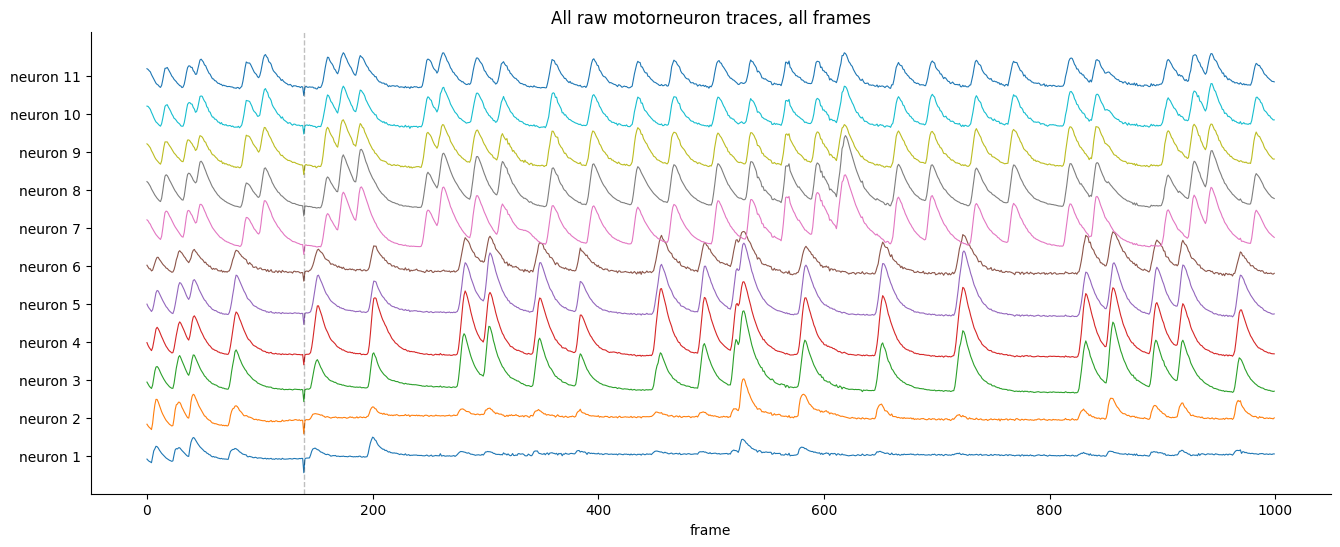

In [14]:
full_frame_slice = slice(0, n_frames)
fig, ax = plt.subplots(figsize=(16, 6))
offset = np.nanstd(traces[:, full_frame_slice]) * 3
if not np.isfinite(offset) or offset == 0:
    offset = 1.0
FRAME_MARK = 139
for neuron_idx in range(n_neurons):
    ax.plot(
        np.arange(n_frames),
        traces[neuron_idx, full_frame_slice] + neuron_idx * offset,
        lw=0.8,
        label=f"neuron {neuron_idx}",
    )
ax.axvline(FRAME_MARK, color="black", ls="--", lw=1.0, alpha=0.25, label=f"frame {FRAME_MARK}")
ax.set_title("All raw motorneuron traces, all frames")
ax.set_xlabel("frame")
ax.set_yticks([idx * offset for idx in range(n_neurons)])
ax.set_yticklabels([f"neuron {idx+1}" for idx in range(n_neurons)])


In [15]:
results = run_many_methods(
    dataset_key=DATASET_KEY,
    methods=METHODS_TO_RUN,
    n_components=N_COMPONENTS,
    reject_components_by_method={},
    save_outputs=False,
    project_root=PROJECT_ROOT,
    tol=DECOMPOSITION_TOL,
    max_iter=DECOMPOSITION_MAX_ITER,
    random_state=DECOMPOSITION_RANDOM_STATE,
)

summarize_results(results)


,method,dataset_key,data_name,dataset_group,input_shape,components_shape,cleaned_shape_frames_by_neurons,output_dir,saved
0,fastica,motorneurons/fish3_trace2_dff,fish3_trace2_dff,motorneurons,"(11, 1000)","(1000, 11)","(1000, 11)",/Users/sadiqadedayo/Documents/projects/ICA/ica...,False
1,infomax,motorneurons/fish3_trace2_dff,fish3_trace2_dff,motorneurons,"(11, 1000)","(1000, 11)","(1000, 11)",/Users/sadiqadedayo/Documents/projects/ICA/ica...,False
2,sobi,motorneurons/fish3_trace2_dff,fish3_trace2_dff,motorneurons,"(11, 1000)","(1000, 11)","(1000, 11)",/Users/sadiqadedayo/Documents/projects/ICA/ica...,False
3,jade,motorneurons/fish3_trace2_dff,fish3_trace2_dff,motorneurons,"(11, 1000)","(1000, 11)","(1000, 11)",/Users/sadiqadedayo/Documents/projects/ICA/ica...,False


In [16]:
component_count = n_components
FRAME_MARK = 139
for method, result in results.items():
    # Compact IC trace view: all ICs on one axis with vertical offsets.
    fig, (ax_traces, ax_spec) = plt.subplots(
        1,
        2,
        figsize=(24, max(6.5, 0.82 * component_count + 5.0)),
        gridspec_kw={"width_ratios": [7, 3]},
    )

    ic_time_slice = result.ic_comps
    offset = np.nanstd(ic_time_slice) * 3.8
    if not np.isfinite(offset) or offset == 0:
        offset = 1.0

    for comp_idx in range(component_count):
        trace = result.ic_comps[:, comp_idx]
        ax_traces.plot(trace + comp_idx * offset, lw=0.8, label=f"IC {comp_idx}")

    ax_traces.axvline(FRAME_MARK, color="black", ls="--", lw=0.9, alpha=0.25)
    ax_traces.set_title(f"{method.upper()} IC traces (offset)")
    ax_traces.set_xlabel("frame")
    ax_traces.set_yticks([idx * offset for idx in range(component_count)])
    ax_traces.set_yticklabels([f"IC {idx}" for idx in range(component_count)])

    # Keep spectral inspection compact: one Welch curve per IC on a shared axis.
    for comp_idx in range(component_count):
        trace = result.ic_comps[:, comp_idx]
        nperseg = min(250, trace.size)
        noverlap = min(125, max(nperseg - 1, 0))
        freqs, power = welch(trace, fs=sample_rate_hz, nperseg=nperseg, noverlap=noverlap)
        ax_spec.plot(freqs, power, lw=0.75, alpha=0.9, label=f"IC {comp_idx}")

    ax_spec.set_xlim(0, sample_rate_hz / 2)
    ax_spec.tick_params(axis="both", labelsize=8)
    ax_spec.set_title(f"{method.upper()} IC Welch spectra")
    ax_spec.set_xlabel("Hz")
    ax_spec.set_ylabel("power")

    ncols = 1 if component_count <= 8 else 2
    ax_traces.legend(loc="upper right", ncols=ncols, fontsize=8)
    ax_spec.legend(loc="upper right", ncols=ncols, fontsize=8)
    fig.suptitle(f"Inspect ICs for {method.upper()} before choosing accepted components", y=1.01)
    fig.tight_layout()

IndentationError: unindent does not match any outer indentation level (<string>, line 5)

## Choose ICs To Accept

After inspecting the IC traces and spectra above, edit the next cell. Each method starts with all ICs accepted. Remove the indices you do not want to keep, or replace a method value with a shorter Python list.


In [ ]:
ACCEPT_COMPONENTS_BY_METHOD = {
    method: list(range(n_components))
    for method in METHODS_TO_RUN
}

# Example after review:
# ACCEPT_COMPONENTS_BY_METHOD["fastica"] = [0, 2, 5]

ACCEPT_COMPONENTS_BY_METHOD = {
    "fastica": [0, 2, 3, 4, 5, 9],
    "infomax": [0, 1, 5, 7, 9, 10],
    "sobi":    [2, 4, 5, 7],
    "jade":    [0, 1, 5, 6, 7, 9, 10],
}



In [ ]:
accepted_cleaned_by_method = {}
reject_components_by_method = {}
saved_paths_by_method = {}
selection_rows = []

for method, result in results.items():
    accepted_components = ACCEPT_COMPONENTS_BY_METHOD.get(method)
    reject_components = accepted_to_rejected(accepted_components, result.ic_comps.shape[1])
    reject_components_by_method[method] = reject_components
    accepted_cleaned = reconstruct_bss(result.ic_comps, result.A, result.mean, reject=reject_components)
    accepted_cleaned_by_method[method] = accepted_cleaned
    selection_rows.append(
        {
            "method": method,
            "accepted_components": (
                "all" if accepted_components is None else sorted({int(component) for component in accepted_components})
            ),
            "rejected_components": reject_components,
            "n_accepted": result.ic_comps.shape[1] - len(reject_components),
            "n_rejected": len(reject_components),
        }
    )

    if SAVE_OUTPUTS:
        out_dir = output_directory(method, result.dataset.data_name, PROJECT_ROOT, dataset_group=result.dataset.group)
        saved_paths_by_method[method] = save_bss_outputs(
            spec=result.dataset,
            method=method,
            traces=result.traces,
            ic_comps=result.ic_comps,
            IC_ft=result.IC_ft,
            A=result.A,
            mean=result.mean,
            cleaned=accepted_cleaned,
            reject_components=reject_components,
            output_dir=out_dir,
            n_components=result.ic_comps.shape[1],
            tol=DECOMPOSITION_TOL,
            max_iter=DECOMPOSITION_MAX_ITER,
            random_state=DECOMPOSITION_RANDOM_STATE,
        )

pd.DataFrame(selection_rows)


In [ ]:
for method, cleaned in accepted_cleaned_by_method.items():
    fig, axes = plt.subplots(n_neurons, 1, figsize=(16, 1.55 * n_neurons), sharex=True)
    if n_neurons == 1:
        axes = [axes]
    for neuron_idx, ax in enumerate(axes):
        ax.plot(
            np.arange(n_frames),
            traces[neuron_idx, full_frame_slice],
            lw=0.75,
            label="raw",
            color="red",
            alpha=0.65,
        )
        ax.plot(
            np.arange(n_frames),
            cleaned[full_frame_slice, neuron_idx],
            lw=0.75,
            label=f"{method} accepted-IC cleaned",
            color="blue",
            alpha=0.8,
        )
        ax.axvline(FRAME_MARK, color="black", ls="--", lw=0.9, alpha=0.85)
        ax.set_ylabel(f"neuron {neuron_idx}")
        ax.legend(loc="upper right", fontsize=8)
    axes[0].set_title(f"All raw vs accepted-IC cleaned traces, all frames, {method}")
    axes[-1].set_xlabel("frame")
    fig.tight_layout()


In [ ]:
for method, result in results.items():
    if method in saved_paths_by_method:
        print(f"{method}:")
        print(f"  accepted: {ACCEPT_COMPONENTS_BY_METHOD.get(method)}")
        print(f"  rejected: {reject_components_by_method[method]}")
        for label, path in saved_paths_by_method[method].items():
            print(f"  {label}: {path.relative_to(PROJECT_ROOT)}")
    else:
        print(
            f"{method}: not saved; set SAVE_OUTPUTS = True and rerun the acceptance/save cell "
            f"to write outputs under {result.output_dir.relative_to(PROJECT_ROOT)}"
        )
